In [1]:
# Core
import pandas as pd
import numpy as np

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load preprocessed data
X_train = pd.read_csv("../data/preprocessed/X_train.csv")
X_test  = pd.read_csv("../data/preprocessed/X_test.csv")
y_train = pd.read_csv("../data/preprocessed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/preprocessed/y_test.csv").values.ravel()

X_train.shape, X_test.shape


((403, 23), (101, 23))

In [3]:
#Initialize All Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200),
    "SVR": SVR(),
    "XGBoost Regressor": XGBRegressor(objective='reg:squarederror')
}

In [4]:
#Train & Evaluate All Models

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])


Training Linear Regression...

Training Decision Tree...

Training Random Forest...

Training SVR...

Training XGBoost Regressor...


In [5]:
#Create Comparison Table

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2"]
)

# Sort by BEST metric → R2 Score (higher is better)
results_df = results_df.sort_values(by="R2", ascending=False)

results_df


,Model,MAE,MSE,RMSE,R2
2,Random Forest,0.465798,0.307650,0.554662,0.160233
4,XGBoost Regressor,0.447713,0.370661,0.608819,-0.011761
3,SVR,0.506472,0.386182,0.621435,-0.054128
0,Linear Regression,0.567298,0.456393,0.675569,-0.245778
1,Decision Tree,0.565278,0.625793,0.791071,-0.708174


In [6]:
#Save the Comparison Table (Regression version)
results_df.to_csv("../data/preprocessed/model_performance.csv", index=False)
print("Saved as model_performance.csv")

Saved as model_performance.csv


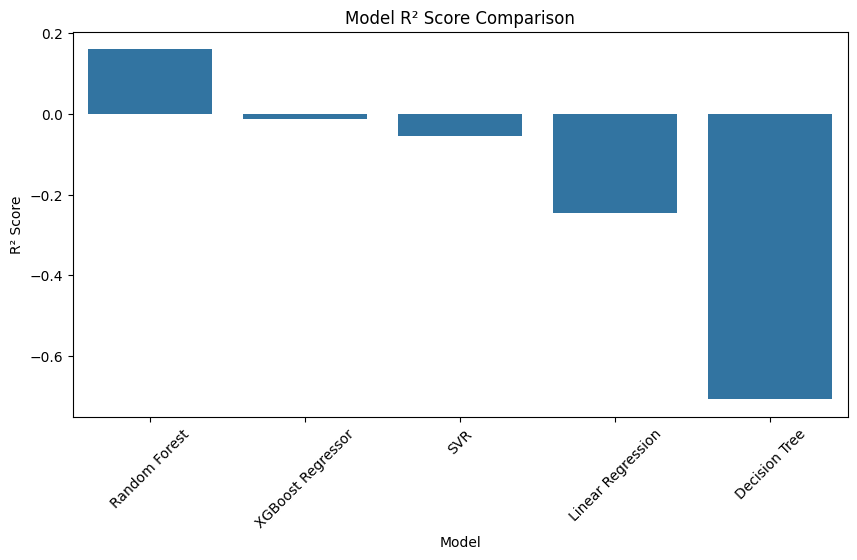

In [8]:
#Plot R² Score Comparison ( for dashboard)

#Since regression does NOT use accuracy, we plot R² Score (higher = better).

plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Model R² Score Comparison")
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.show()

Best Model: Random Forest


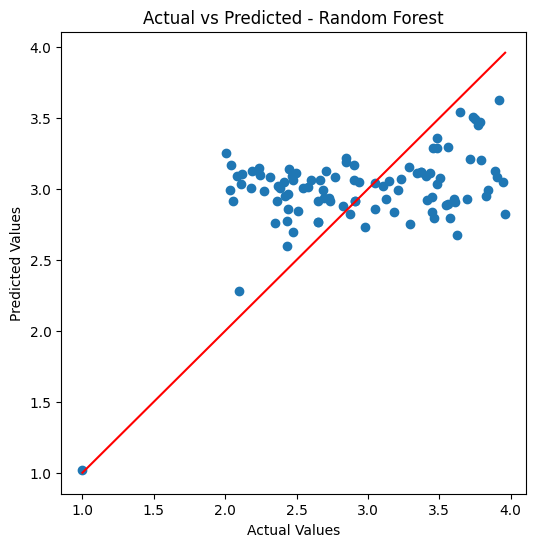

In [9]:
#Plot Predicted vs Actual for Best Model (Correct regression version)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # ideal line
plt.show()

In [10]:
#Save Best Regression Model for Dashboard

#No change needed — works for regression also:

import pickle

with open("../dashboard/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Saved best model to dashboard/best_model.pkl")

Saved best model to dashboard/best_model.pkl
